In [2]:
#Convolution Neural Network using PyTorch for MNIST Dataset

#Import packages
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import torchvision.datasets as dsets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [3]:
#Setup the CNN Sub class for MNIST Dataset

class CNNNeuralNet(nn.Module):

    def __init__(self, in_size=1, out1_size=64, out2_size=128):
        super().__init__()

        self.cnn1 = nn.Conv2d(in_channels=in_size,out_channels=out1_size,kernel_size=3,padding=1) # 64x28x28
        self.maxpool1 = nn.MaxPool2d(kernel_size=2,stride=2) # stride=2 reduces dim by half 64x14x14

        self.cnn2 = nn.Conv2d(in_channels=out1_size,out_channels=out2_size,kernel_size=3,stride=1,padding=1) # 128x14x14
        self.maxpool2 = nn.MaxPool2d(kernel_size=2,stride=2) # 128x7x7

        self.flatten  = nn.Flatten()

        self.fc1 =  nn.Linear(out2_size*7*7,64) # 128*7*7 -> 64
        self.fc2 =  nn.Linear(64,32) # 64 -> 32
        self.fc3 =  nn.Linear(32,10) # 32 -> 10 ( 10 output channels in MNIST)

        

    def forward(self,x):
        
        x = torch.relu(self.cnn1(x))
        x = self.maxpool1(x)
    
        x = torch.relu(self.cnn2(x))
        x = self.maxpool2(x)

        x = self.flatten(x)

        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)

        return x

In [4]:
# setup the dataset

train_dataset = dsets.MNIST(root = './Data',download=True,train=True,transform=transforms.ToTensor())
test_dataset = dsets.MNIST(root = './Data',download=True,train=False,transform=transforms.ToTensor())

train_loader = DataLoader(dataset=train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(dataset=test_dataset,batch_size=128,shuffle=False)

100%|██████████| 9.91M/9.91M [00:05<00:00, 1.74MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 120kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.11MB/s]
100%|██████████| 4.54k/4.54k [00:00<?, ?B/s]


In [5]:
#Setup model training parameters

model = CNNNeuralNet()
print(f"Model architecture: {model.state_dict()}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

epochs = 5

Model architecture: OrderedDict({'cnn1.weight': tensor([[[[ 4.9975e-02, -1.2810e-01, -7.1464e-02],
          [ 2.4392e-01,  1.1714e-01, -1.7991e-01],
          [ 2.0670e-01,  1.3466e-01,  1.1104e-01]]],


        [[[ 2.4895e-02, -2.3717e-01,  1.1577e-01],
          [-1.1628e-01,  2.1491e-01,  1.8536e-02],
          [ 8.2288e-02,  3.3775e-02,  1.4930e-01]]],


        [[[ 4.2402e-02,  2.5072e-01, -1.8926e-01],
          [ 1.6713e-01,  5.4767e-02,  1.5318e-01],
          [-5.9039e-03, -2.1855e-01,  2.2995e-01]]],


        [[[ 2.1974e-01, -3.2270e-03, -2.4726e-01],
          [ 2.4156e-01,  2.1108e-01, -1.5257e-02],
          [ 1.7317e-01, -4.4194e-02, -2.5622e-01]]],


        [[[-2.4915e-02,  3.2509e-01, -1.9396e-01],
          [ 2.7368e-01, -3.4416e-02, -1.3836e-01],
          [ 1.1867e-01,  2.3753e-01,  1.3527e-01]]],


        [[[-1.5528e-01, -1.6604e-02, -6.5429e-02],
          [ 1.6232e-01,  1.5730e-02, -1.5859e-01],
          [-1.7035e-01,  2.4234e-01, -2.4323e-01]]],


        [[

In [6]:
#Train the model - setup training loop

model_metrics = { 'Training_Loss':[], 'Validation_Accuracy': []}

def train_model(n_epochs):
    for epoch in range(n_epochs):
        running_loss = 0
        model.train()
        for x,y in train_loader:
            optimizer.zero_grad()
            yhat = model(x)
            loss = criterion(yhat,y)
            running_loss += loss.item() 
            loss.backward()
            optimizer.step()
        training_loss = running_loss / len(train_loader)
        model_metrics['Training_Loss'].append(training_loss)

        model.eval()
        with torch.no_grad():
            correct = 0
            for x_test,y_test in test_loader:
                z = model(x_test)
                _,yhat = torch.max(z, dim=1)
                correct += (yhat==y_test).sum().item()
            validation_accuracy = correct / len(test_loader.dataset)
            model_metrics['Validation_Accuracy'].append(validation_accuracy)
        
        #if(epoch+1) % 5 == 0:
        print(f"Training Loss: {model_metrics['Training_Loss'][-1]: .4f}",flush=True)
        print(f"Validation Accuracy: {model_metrics['Validation_Accuracy'][-1]: .4f}",flush=True)

#Call the training function
train_model(epochs)

Training Loss:  0.1729
Validation Accuracy:  0.9774
Training Loss:  0.0539
Validation Accuracy:  0.9831
Training Loss:  0.0373
Validation Accuracy:  0.9904
Training Loss:  0.0280
Validation Accuracy:  0.9888
Training Loss:  0.0225
Validation Accuracy:  0.9880


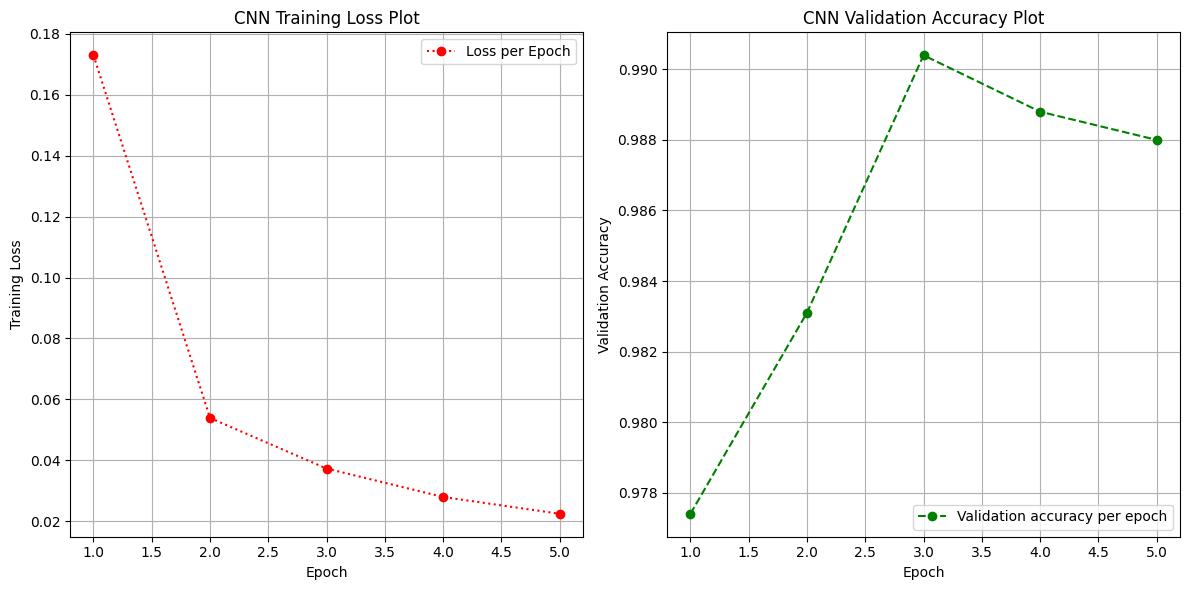

In [7]:
# Plot the training loss and validation accuracy

_,(ax1,ax2) =  plt.subplots(1,2,figsize=(12,6))

ax1.plot(range(1, epochs+1), np.array(model_metrics['Training_Loss']), marker='o', color='r', ls=':', label='Loss per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('CNN Training Loss Plot')
ax1.legend()
ax1.grid()

ax2.plot(range(1, epochs+1),np.array(model_metrics['Validation_Accuracy']), marker = 'o',color = 'g', ls='--',label='Validation accuracy per epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Accuracy')
ax2.set_title('CNN Validation Accuracy Plot')
ax2.legend()
ax2.grid()

plt.tight_layout()

plt.show()


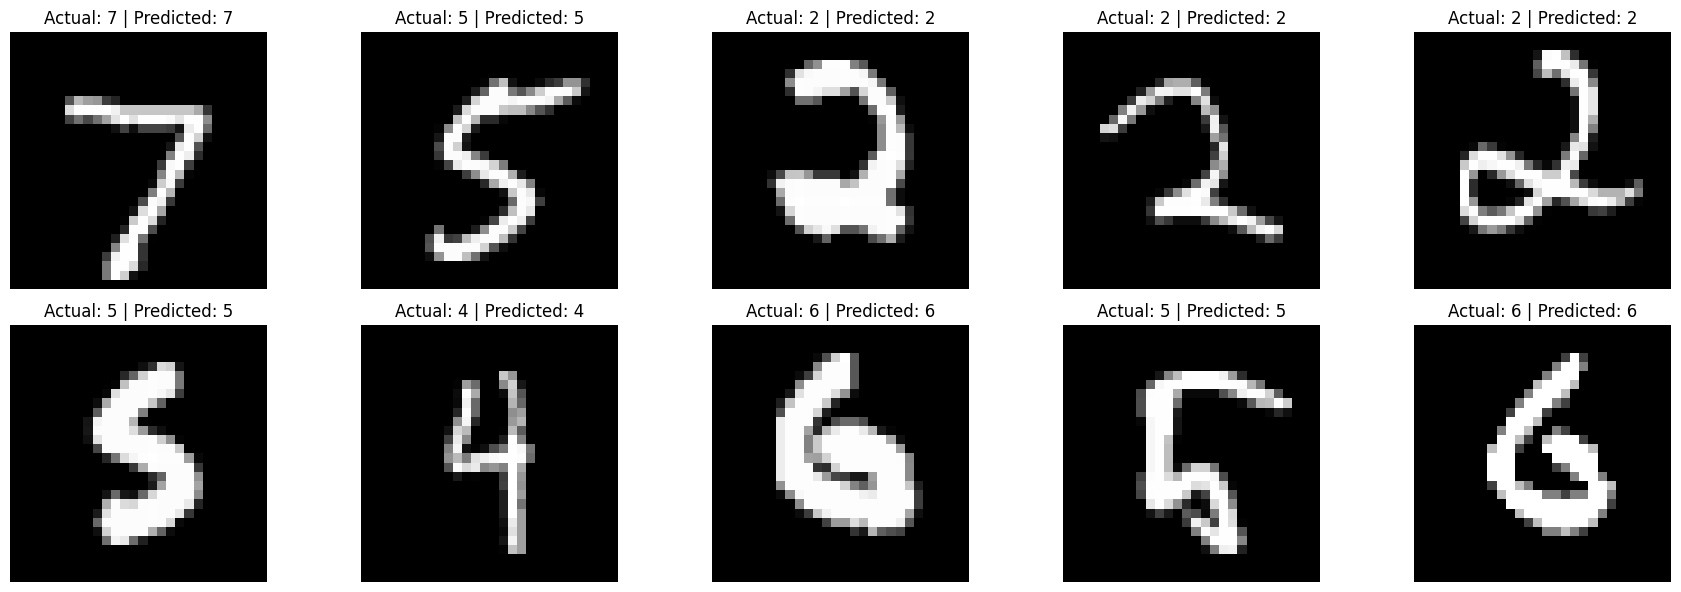

In [16]:
#Plot the actual and predicted labels along the orginal image
model.eval()
fig, axes = plt.subplots(2, 5, figsize=(18, 6)) 

axes = axes.flatten()
with torch.no_grad():
    for i, (x, y) in zip(range(10), test_loader):
        z = model(x)
        _, yhat = torch.max(z, 1)
        
        axes[i].imshow(x[i].reshape(28,28), cmap='gray') # single image [28,28]
        axes[i].set_title(f'Actual: {y[i].item()} | Predicted: {yhat[i].item()}')
        axes[i].axis('off')
plt.tight_layout(pad=1.0)
plt.show()